In [9]:
import numpy as np
import pandas as pd
from scipy.integrate import odeint
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv("../data/cleaned/os_model_data.csv")

x_data = df["x"].values
y_data = df["y"].values

x0 = x_data[0]
y0 = y_data[0]

t = np.arange(len(x_data))

In [11]:
def model(z, t, r1, r2, K1, K2, alpha, beta):

    x, y = z

    dx = r1 * x * (1 - x / K1) - alpha * x * y
    dy = r2 * y * (1 - y / K2) - beta * x * y

    return [dx, dy]

In [12]:
def simulate(params):

    r1, r2, K1, K2, alpha, beta = params

    z0 = [x0, y0]

    sol = odeint(
        model,
        z0,
        t,
        args=(r1, r2, K1, K2, alpha, beta)
    )

    x_model = sol[:, 0]
    y_model = sol[:, 1]

    return x_model, y_model

In [13]:
def loss(params):

    x_model, y_model = simulate(params)

    error_x = x_model - x_data
    error_y = y_model - y_data

    return np.sum(error_x**2 + error_y**2)

In [14]:
initial_guess = [0.05, 0.02, 1.0, 0.5, 0.05, 0.05]

bounds = [
    (0, 1),    # r1
    (0, 1),    # r2
    (0.1, 2),  # K1
    (0.1, 2),  # K2
    (0, 1),    # alpha
    (0, 1)     # beta
]

In [15]:
result = minimize(
    loss,
    initial_guess,
    bounds=bounds,
    method="L-BFGS-B"
)

params = result.x

params

array([0.21273747, 0.15018052, 2.        , 0.23991932, 0.56317166,
       0.        ])

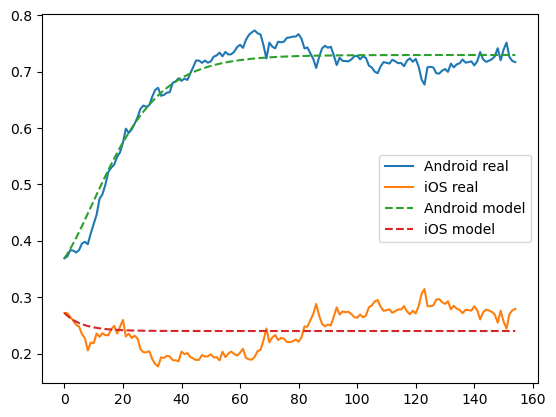

In [ ]:
x_model, y_model = simulate(params)

plt.plot(x_data, label="Android real")
plt.plot(y_data, label="iOS real")

plt.plot(x_model, "--", label="Android model")
plt.plot(y_model, "--", label="iOS model")

plt.legend()
plt.show()